# prep

In [1]:
account_path = '/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/'

In [2]:
# mount the drive
from google.colab import drive
drive.mount('/content/drive/')
from google.colab import auth
auth.authenticate_user()

# load packages - basics
!pip install pynrrd
import os
import csv
import numpy as np
import pandas as pd
import math
import time
import json
import nrrd

Mounted at /content/drive/


In [3]:
# load packages - stats
!pip install scikit-posthocs
import scipy
from scipy import io
from scipy.fftpack import rfft, irfft, fftfreq
import scipy.stats as stats
from scipy.stats import zscore

import statsmodels.api as sm
import statsmodels.formula.api as smf
import scikit_posthocs as scikit
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels

import random
from random import randrange, shuffle
import itertools
from itertools import combinations
import sklearn
from sklearn.decomposition import PCA, FastICA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score

In [4]:
# load packages - plotting and template settings
import matplotlib as mpl
from matplotlib import pyplot as plt
%matplotlib inline

from matplotlib.patches import Rectangle
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import animation
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import pickle

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## fcn.

In [5]:
import gspread
from google.auth import default

def read_metadata(gsheet_url,tab_name):
  """This script reads information in a tab in the Google sheet, where metadata for each experiment is stored.
  """
  # reading in google sheet with experimental details
  creds, _ = default()
  gc = gspread.authorize(creds)

  # insert URl of gsheet, specify worksheets as different variables
  wb = gc.open_by_url(gsheet_url)
  exps = wb.worksheet(tab_name)

  all_data = pd.DataFrame(exps.get_all_records())
  metadata = all_data.set_index('experiment')
  display(all_data)

  return metadata

In [6]:
from scipy.interpolate import interp1d
def resample_to_max_length(list_of_arrays):
    max_len = max(len(arr) for arr in list_of_arrays)
    resampled = []
    for arr in list_of_arrays:
        x_old = np.linspace(0, 1, len(arr))
        x_new = np.linspace(0, 1, max_len)
        f = interp1d(x_old, arr, kind='linear', fill_value='extrapolate')
        resampled.append(f(x_new))
    return np.array(resampled), max_len

## config

In [7]:
# figures output parameters
mpl.rcParams['lines.linewidth'] = 1        # default line width
mpl.rcParams['patch.linewidth'] = 0
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

# Set global Matplotlib parameters for PDF output
mpl.rcParams['pdf.fonttype'] = 42          # Use TrueType fonts (editable text)

mpl.rcParams['figure.figsize'] = (4,3)     # Default figure size in inches
mpl.rcParams['axes.titlesize'] = 16        # Title font size
mpl.rcParams['axes.labelsize'] = 14        # Axis label font size
mpl.rcParams['xtick.labelsize'] = 10       # X-axis tick label size
mpl.rcParams['ytick.labelsize'] = 10       # Y-axis tick label size
mpl.rcParams['legend.fontsize'] = 8        # Legend font size
mpl.rcParams['savefig.dpi'] = 300          # DPI for high-quality export (relevant for raster elements)
mpl.rcParams['savefig.transparent'] = True # Ensures background is transparent
sns.set(style="white",font_scale=1)     # global scaling of all texts
mpl.rcParams['xtick.bottom'] = True        # make sure ticks visible
mpl.rcParams['ytick.left'] = True

mpl.rcParams['xtick.major.width'] = 0.5    # X-axis major tick width
mpl.rcParams['ytick.major.width'] = 0.5    # Y-axis major tick width
mpl.rcParams['axes.linewidth'] = 0.5       # Axis line width

from cycler import cycler
# remove red from the default colors
mpl.rcParams['axes.prop_cycle'] = cycler('color', ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])

In [8]:
figure_path = account_path + 'Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/'
csv_path = account_path + 'Yu_escape_paper/Manuscript/Figures/figures_v8/csvs/'

# Data (2p - dots)

In [12]:
# directories for the data and analysis
gsheet = 'https://docs.google.com/spreadsheets/d/1tpUkPiWTz_j2fthNLOIQvooPCbYnScKaoHLthi5yq18/edit?gid=106031496#gid=106031496'
tab_name = 'four_stim'

path = account_path + 'Yu_escape_paper/Imaging/Dots_do_stuff/'
data_path = path + 'Data/'
save_path = path + 'Analysis/'

metadata = read_metadata(gsheet,tab_name)
experiments = metadata.index
fcn_files = metadata.fcn_file
planeNum = metadata.planeNum
trialNum = metadata.trialNum

,experiment,fcn_file,planeNum,ROI_csv,trialNum,atlas_1,atlas_2,
0,jy-241126-f2,t2-stimR,2,2,10 9 10 10,58-77,65-84,
1,jy-241126-f4,t1-stimL,2,2,6 6 5 6,69-62,81-76,
2,jy-241126-f4,t2-stimR,2,2,5 4 5 4,76-69,83-77,
3,jy-241126-f4,t3-stimL,2,2,4 4 4 4,68-60,80-73,
4,jy-241203-f2,t1-stimL,2,2,7 7 7 8,76-58,91-74,
5,jy-241203-f2,t2-stimR,2,2,8 9 8 9,78-60,98-80,
6,jy-241203-f2,t3-stimR,1,1,10 10 10 9,88-70,,
7,jy-241203-f3,t1-stimL,2,2,9 9 10 9,75-68,88-83,
8,jy-241203-f3,t2-stimR,2,2,10 10 10 10,77-71,86-80,good brain
9,jy-241203-f3,t3-stimL,1,1,8 8 9 8,72-66,,


## stim type color scheme

In [13]:
# establish stim type num, names, and colors
# establish stim type num, names, and colors
resample_Hz = 10
pre, stim_dur, post = [sec*resample_Hz for sec in [5, 6, 14]] # baseline/stim on/ITI
off = 3*resample_Hz # potential response window to offset of stimulus
trial_len = pre+stim_dur+post
stim_names = ['Linear','Loom','BM','BM-escape']

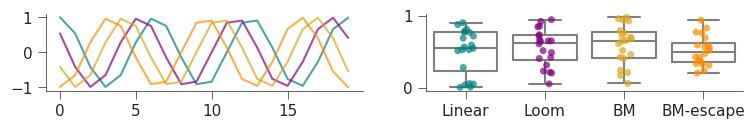

In [14]:
group_num = len(stim_names); group_names = stim_names
tmp = {n: np.random.random(20) for n in stim_names};

stim_colorz = ['teal','purple','goldenrod','darkorange']
# validate colors settings work with both major plotting packages
plt.figure(figsize=[9,1]); plt.subplot(121);
for igs, gs in enumerate(group_names):
  plt.plot(np.cos(np.arange(igs,igs+20)),c=stim_colorz[igs],alpha=0.7);
tmp = {n: np.random.random(20) for n in group_names};
plt.subplot(122); sns.boxplot(data=tmp,fill=False,color='gray');
sns.stripplot(data=tmp,palette=stim_colorz,alpha=0.7); sns.despine();
plt.show()

# 4a - 2p imaging setup

# 4b - roi extraction pipeline

fish # jy-241203-f3 :  t1-stimL
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/4b-all_locations


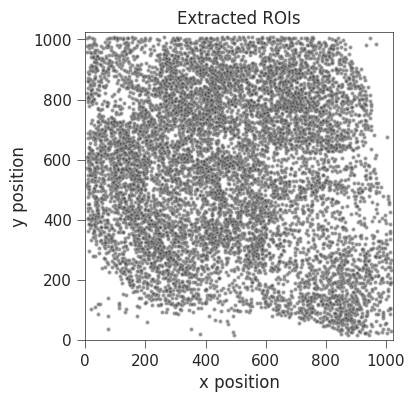

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/4b-corr_colored


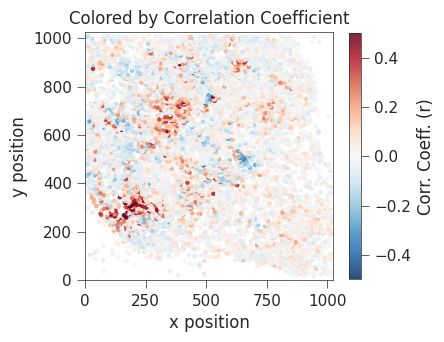

In [ ]:
subpanel = '4b'

rep_exp_ffile = ['jy-241203-f3,t1-stimL']
for rep_exp in rep_exp_ffile:
  rep_exp, rep_ffile = rep_exp.split(',')
  for exp, ffile, plane_num, trial_num in zip(experiments[:], fcn_files[:], planeNum[:], trialNum[:]):
    if exp != rep_exp or ffile != rep_ffile: continue
    load_path = data_path + exp + '/' + ffile + '/'; output_path = save_path + exp + '/' + ffile + '/'
    print("fish #", exp, ': ', ffile)

    # load processed 2p info
    data = np.load(load_path+'neuron_details.npz', allow_pickle=True)
    traces_Z, xs, ys, zs = data['traces_Z'], data['xs'], data['ys'], data['zs']
    # load stimulus
    data = np.load(load_path+'regressors.npz', allow_pickle=True)
    stimuli = data['stimuli']

    # Load correlation data for ROI coloring
    data = np.load(output_path+'pearson_corr.npz', allow_pickle=True)
    corr = data['corr']
    corr_coeffs = corr[2] # correlation to swim

    ## 1. Plot ROI locations (x/y coordinates)
    fig, ax = plt.subplots(1, 1, figsize=(4,4))
    ax.scatter(xs, ys, marker='o', s=5, alpha=0.5, ec = '0.6', fc='0.1')
    ax.set_xlabel('x position'); ax.set_ylabel('y position')
    ax.set_xlim(0,1024); ax.set_ylim(0,1024)
    ax.set_title('Extracted ROIs')
    ax.set_aspect('equal')

    print(figure_path+subpanel+'-all_locations')
    plt.savefig(figure_path+subpanel+"-all_locations.pdf",bbox_inches='tight')
    plt.show()

    ## 2. Plot ROI locations colored by correlation coefficient
    fig, ax = plt.subplots(1, 1, figsize=(4,4))
    scatter = ax.scatter(xs, ys, c=corr_coeffs, fc=corr_coeffs, cmap='RdBu_r', marker='o', s=5, alpha=0.85, vmin=-0.5, vmax=0.5)
    ax.set_xlabel('x position'); ax.set_ylabel('y position')
    ax.set_xlim(0,1024); ax.set_ylim(0,1024)
    ax.set_title('Colored by Correlation Coefficient')
    ax.set_aspect('equal')

    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax, label='Corr. Coeff. (r)',shrink=0.8)

    print(figure_path+subpanel+'-corr_colored')
    plt.savefig(figure_path+subpanel+"-corr_colored.pdf",bbox_inches='tight')
    plt.show()

    # save source data into csv
    series_dict = {'x': xs, 'y': ys, 'corr': corr_coeffs}
    df = pd.DataFrame(series_dict)
    df.to_csv(csv_path+subpanel+'.csv', index=False)

# 4c - mean maxZ to linear/bm/escp

Each point is average of all cells in a session
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/4c


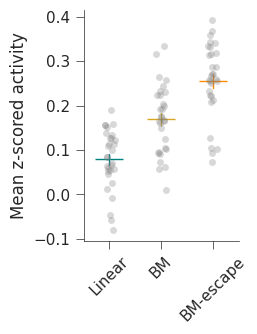

Ns, means, and  sems for data:
Linear: N=30 0.080 ± 0.012
BM: N=30 0.170 ± 0.014
BM-escape: N=30 0.256 ± 0.016

Normality test (Shapiro-Wilk):
Group Linear: W = 0.949, p = 0.161
Group BM: W = 0.985, p = 0.930
Group BM-escape: W = 0.927, p = 0.040
not all groups are normally distributed → use nonparametric test.

Kruskal-Wallis H-test: H = 42.254, p = 6.677669990324025e-10

Dunn's post hoc test with bonferroni correction:  ['Linear', 'BM', 'BM-escape']
              1         2             3
1  1.000000e+00  0.002097  2.437213e-10
2  2.096930e-03  1.000000  5.644904e-03
3  2.437213e-10  0.005645  1.000000e+00


In [ ]:
subpanel = '4c'
stim_names_tmp = ['Linear','BM','BM-escape']
stim_colorz_tmp = ['teal','goldenrod','darkorange']

pre, stim_dur, post = [sec*resample_Hz for sec in [5, 6, 14]] # baseline/stim on/ITI
off = 3*resample_Hz # potential response window to offset of stimulus
trial_len = pre+stim_dur+post

# get basic metrics of neuron responses for each stim
MAX_F = {n: [] for n in stim_names}
MEAN_F = {n: [] for n in stim_names}
CELL_RATIO = {n: [] for n in stim_names}

for exp, ffile, plane_num, trial_num in zip(experiments, fcn_files, planeNum, trialNum):
  [t1, t2, t3, t4] = [int(t) for t in trial_num.split(' ')]
  load_path = data_path + exp + '/' + ffile + '/'; output_path = save_path + exp + '/' + ffile + '/'

  # load PSTHs
  with open(output_path+'PSTHs.pkl', 'rb') as f:
    PSTHs = pickle.load(f) # cell_num x stim_types x x [trial_num for stim in stim_names]
  cell_num = len(PSTHs)
  # load responsive cells
  data = np.load(output_path+'ttest_cells_long.npz',allow_pickle=True)
  cell_id, resp_arr = data['cell_id'], data['resp_arr']

  # print(f"fish {exp}: {ffile}")
  # get metrics
  maxf = [[] for i in range(len(stim_names))]
  meanf = [[] for i in range(len(stim_names))]

  for i in range(len(stim_names)):
    for cell in cell_id[resp_arr[i]==True]:
      stim_psths = np.array(PSTHs[cell][i])
      maxf[i].append(np.nanmean(np.nanmax(stim_psths[:,pre:pre+stim_dur+off])))
      meanf[i].append(np.nanmean(np.nanmean(stim_psths[:,pre:pre+stim_dur+off])))

  # append to fish summary stats
  for i, stim in enumerate(stim_names):
    MAX_F[stim].append(np.mean(maxf[i]))
    MEAN_F[stim].append(np.mean(meanf[i]))
    CELL_RATIO[stim].append(len(cell_id[resp_arr[i]==True])/cell_num)

# remove loom data
MAX_F.pop('Loom'); MEAN_F.pop('Loom'); CELL_RATIO.pop('Loom')

# PLOT
print('Each point is average of all cells in a session')

plt.figure(figsize=[2,3])
sns.stripplot(data=MEAN_F,color='gray',alpha=0.3,size=5)
sns.pointplot(data=MEAN_F,palette=stim_colorz_tmp,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);
plt.ylabel('Mean z-scored activity')
plt.xticks(range(len(stim_names)-1),stim_names_tmp,rotation=45)
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

# stats
group_values = MEAN_F
group_sizes = list(group_values.keys())
groups = group_values.keys()
summary_data = group_values.values()
print("Ns, means, and  sems for data:")
for id, s in enumerate(summary_data):
  print(f"{group_sizes[id]}: N={len(s)} {np.mean(s):.3f} ± {scipy.stats.sem(s):.3f}")

## -- 1. Test for normality in each group -- ##
print("\nNormality test (Shapiro-Wilk):")
normality_results = {}
for group, data in zip(groups, summary_data):
  stat, p = stats.shapiro(data)
  normality_results[group] = {'W': stat, 'p': p}
for g, res in normality_results.items():
  print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.3f}")

is_normal = all(res['p'] > 0.05 for res in normality_results.values());
if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
else: print("not all groups are normally distributed \u2192 use nonparametric test.")

## -- 2. Group comparisons (& post hoc test) -- ##
unique_groups = len(groups); annotation_dict = {}
if unique_groups == 2:
  groups = list(groups); summary_data = group_values
  #  Two groups: t-test or Mann-Whitney
  if is_normal:
    stat, p = stats.ttest_ind(summary_data[groups[0]], summary_data[groups[1]])
    print(f"\nT-test: t = {stat:.3f}, p = {p:.5f}")
  else:
    stat, p = stats.mannwhitneyu(summary_data[groups[0]], summary_data[groups[1]])
    print(f"\nMann-Whitney U: U = {stat:.3f}, p = {p:.5f}")
  annotation_dict[(groups[0], groups[1])] = p

elif unique_groups > 2:
  if is_normal: # One-way ANOVA
    summary_data = list(group_values.values())
    groups = list(group_values.keys())
    # model = smf.ols(summary_data, groups).fit()
    df = pd.DataFrame({'data': np.concatenate(summary_data), 'group': np.repeat(groups, [len(d) for d in summary_data])})
    # Define the formula
    formula = 'data ~ group'
    # Fit the model
    model = smf.ols(formula, data=df).fit() # Changed this line
    anova_table = sm.stats.anova_lm(model, typ=2)
    print("\nOne-way ANOVA:\n", anova_table)
    if anova_table['PR(>F)'][0] < 0.05:
      flat_data = [val for sublist in summary_data for val in sublist]
      groups = [group_names[i] for i, sublist in enumerate(summary_data) for _ in sublist]
      tukey = pairwise_tukeyhsd(endog=flat_data, groups=groups, alpha=0.05)
      print("\nTukey's HSD post hoc test:\n", tukey.summary())
      for res in tukey._results_table.data[1:]:
        g1, g2, p = res[0], res[1], res[4]
        annotation_dict[(g1, g2)] = p

  else: # Kruskal-Wallis test
    stat, p = stats.kruskal(*summary_data)
    print(f"\nKruskal-Wallis H-test: H = {stat:.3f}, p = {p}")
    if p < 0.05:
      # Dunn's post hoc test with Bonferroni correction
      data_for_dunn = list(summary_data); group_for_dunn = list(groups)
      dunn = scikit.posthoc_dunn(data_for_dunn, p_adjust='bonferroni')
      print("\nDunn's post hoc test with bonferroni correction: ",group_for_dunn)
      print(dunn)
      for g1, g2 in combinations(list(dunn.keys()), 2): annotation_dict[(g1, g2)] = dunn.loc[g1, g2]

# save source data into csv
series_dict = {}
for key, values in group_values.items(): series_dict[key] = pd.Series(values)

df = pd.DataFrame(series_dict)
df.to_csv(csv_path+subpanel+'.csv', index=False)

In [ ]:
# STATS - MLB with Mixed Effects Model # update fish_ids (random effect)
import pandas as pd
import statsmodels.formula.api as smf
from itertools import combinations

# stats
group_values = MEAN_F
group_sizes = list(group_values.keys())
groups = group_values.keys()
summary_data = group_values.values()
print("Ns, means, and  sems for data:")
for id, s in enumerate(summary_data):
  print(group_sizes[id], len(s), np.mean(s), scipy.stats.sem(s))

## -- Mixed Effects Model Analysis -- ##
print("\nMixed Effects Model Analysis:")
print("Using fish ID as random effect")

# Create fish IDs for each data point (assuming each value in summary_data comes from a different fish)
fish_ids = []
group_labels = []
all_values = []

for group_idx, (group_name, data) in enumerate(zip(groups, summary_data)):
    # Create unique fish IDs for this group
    group_fish_ids = [f"fish_{i}" for i in range(len(data))]
    fish_ids.extend(group_fish_ids)
    group_labels.extend([group_name] * len(data))
    all_values.extend(data)

# Create DataFrame for mixed effects model
df = pd.DataFrame({
    'cell_values': all_values,
    'group': group_labels,
    'fish_ID': fish_ids
})

# Convert group to categorical
df['group'] = df['group'].astype('category')

print(f"Total observations: {len(df)}")
print(f"Groups: {df['group'].unique()}")
print(f"Fish per group: {df.groupby('group').size().to_dict()}")

## -- Pairwise comparisons using mixed effects models -- ##
annotation_dict = {}

if len(groups) == 2:
    # Two groups comparison
    print(f"\nMixed effects model comparison: {groups[0]} vs {groups[1]}")

    # Fit mixed effects model
    model = smf.mixedlm("cell_values ~ group", df, groups=df['fish_ID'])
    result = model.fit()

    # Extract p-value for group effect
    p_values = result.pvalues
    group_p_value = p_values.iloc[1]  # Second parameter is usually the group effect

    print(f"Group effect p-value: {group_p_value:.10e}")
    annotation_dict[(groups[0], groups[1])] = group_p_value

elif len(groups) > 2:
    # Multiple groups - pairwise comparisons
    print(f"\nPairwise mixed effects model comparisons:")

    for g1, g2 in combinations(groups, 2):
        print(f"\nComparing {g1} vs {g2}")

        # Subset data for this comparison
        subset_df = df[df['group'].isin([g1, g2])].copy()
        subset_df['group'] = subset_df['group'].cat.remove_unused_categories()

        # Fit mixed effects model for this pair
        model = smf.mixedlm("cell_values ~ group", subset_df, groups=subset_df['fish_ID'])
        result = model.fit()
        print(result.summary())
        print("Random effect (fish_ID) variance:", result.cov_re.iloc[0,0])

        # Extract p-value for group effect
        p_values = result.pvalues
        group_p_value = p_values.iloc[1]  # Second parameter is usually the group effect

        print(f"  Group effect p-value: {group_p_value:.10e}")
        annotation_dict[(g1, g2)] = group_p_value

Ns, means, and  sems for data:
Linear 30 0.07965489803421254 0.012293099997097061
BM 30 0.1697487178426867 0.014198054325836035
BM-escape 30 0.2563592023275818 0.015581997942540416

Mixed Effects Model Analysis:
Using fish ID as random effect
Total observations: 90
Groups: ['Linear', 'BM', 'BM-escape']
Categories (3, object): ['BM', 'BM-escape', 'Linear']
Fish per group: {'BM': 30, 'BM-escape': 30, 'Linear': 30}

Pairwise mixed effects model comparisons:

Comparing Linear vs BM
          Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: cell_values
No. Observations:  60      Method:             REML       
No. Groups:        30      Scale:              0.0027     
Min. group size:   2       Log-Likelihood:     70.1904    
Max. group size:   2       Converged:          Yes        
Mean group size:   2.0                                    
----------------------------------------------------------
                Coef.  Std.Err.   z    P>|z| [0.025 0.97

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


           Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: cell_values
No. Observations:   60      Method:             REML       
No. Groups:         30      Scale:              0.0037     
Min. group size:    2       Log-Likelihood:     65.3833    
Max. group size:    2       Converged:          Yes        
Mean group size:    2.0                                    
-----------------------------------------------------------
                Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept        0.256    0.014  18.267 0.000  0.229  0.284
group[T.Linear] -0.177    0.016 -11.317 0.000 -0.207 -0.146
Group Var        0.002    0.025                            

Random effect (fish_ID) variance: 0.0022515305142533516
  Group effect p-value: 1.0862770904e-29

Comparing BM vs BM-escape
           Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  cell_val

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


# 4d (cartoon of small stimuli)

## 4e - example off cells heatmaps


fish # jy-241204-f3 :  t1-stimL
total n = 2610 socially responsive cells - showing 500 cells here
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/4e-rastermap_fish1


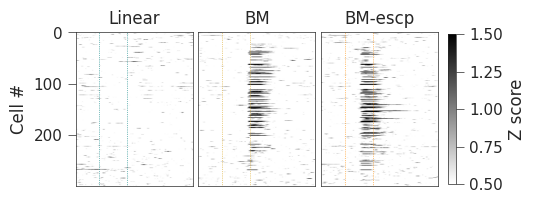

,Linear_1,Linear_2,Linear_3,Linear_4,Linear_5,Linear_6,Linear_7,Linear_8,Linear_9,Linear_10,...,BM-escp_291,BM-escp_292,BM-escp_293,BM-escp_294,BM-escp_295,BM-escp_296,BM-escp_297,BM-escp_298,BM-escp_299,BM-escp_300
0,0.133065,0.251400,-0.153428,-0.908813,0.578686,-0.064546,0.075997,0.673165,-0.022023,-0.284151,...,-0.393499,-0.144854,0.323214,0.117148,0.209018,0.238784,0.278432,0.213068,-0.421195,0.226656
1,0.000797,0.257774,-0.274895,-0.988434,0.658217,-0.183035,0.184785,0.601334,-0.067766,-0.312686,...,-0.330931,-0.153275,0.419549,0.190603,0.414654,0.179521,0.176394,0.222511,-0.446857,0.326242
2,-0.090566,0.233289,-0.327328,-0.980232,0.673040,-0.143115,0.294510,0.497777,-0.076535,-0.343152,...,-0.304274,-0.174818,0.495701,0.223330,0.605795,0.128668,0.080706,0.227918,-0.421178,0.427181
3,-0.079403,0.169048,-0.291658,-0.873574,0.666404,-0.002951,0.371458,0.421051,-0.078989,-0.327709,...,-0.286334,-0.160791,0.557466,0.217665,0.715136,0.107376,0.020125,0.194254,-0.398545,0.459874
4,-0.018751,0.109733,-0.252546,-0.724026,0.664232,0.121395,0.409142,0.312763,-0.074106,-0.335017,...,-0.223365,-0.081699,0.672774,0.308009,0.776810,0.048542,-0.040410,0.083382,-0.394815,0.454833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,0.153515,-0.010806,0.357676,-0.529166,-0.420068,0.149464,0.916186,-0.076782,0.215177,0.602288,...,0.347674,-0.282688,0.302602,-0.402564,-0.047738,-0.194342,-0.234008,0.311423,0.073072,-0.065594
246,0.073010,0.011475,0.180571,-0.613403,-0.319909,0.107403,0.984007,-0.024928,0.270668,0.610778,...,0.216540,-0.269135,0.237852,-0.458213,0.017565,-0.100923,-0.141226,0.214744,-0.000616,-0.085417
247,-0.011465,0.075063,0.009488,-0.736673,-0.219469,0.002847,1.014245,-0.048845,0.371646,0.604227,...,0.176315,-0.246163,0.126073,-0.431120,-0.020855,-0.076531,-0.007896,0.183058,-0.050075,-0.029161
248,-0.011675,0.081033,-0.145822,-0.836341,-0.122282,-0.138901,1.046456,-0.071572,0.491880,0.593818,...,0.200088,-0.239650,0.034486,-0.352189,-0.167124,-0.095448,0.122531,0.077972,-0.088308,0.036153



fish # jy-241204-f3 :  t2-stimR
total n = 2322 socially responsive cells - showing 500 cells here
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/4e-rastermap_fish2


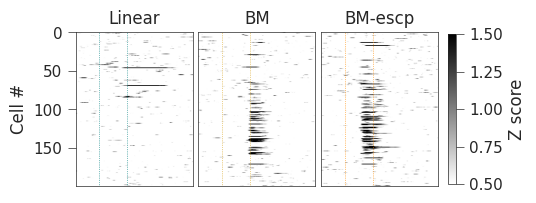

,Linear_1,Linear_2,Linear_3,Linear_4,Linear_5,Linear_6,Linear_7,Linear_8,Linear_9,Linear_10,...,BM-escp_191,BM-escp_192,BM-escp_193,BM-escp_194,BM-escp_195,BM-escp_196,BM-escp_197,BM-escp_198,BM-escp_199,BM-escp_200
0,-0.161283,0.110367,-0.386481,0.100054,0.187830,-0.247290,-0.224472,-0.439232,0.169951,0.044363,...,0.125452,-0.405876,0.103080,-0.100567,-0.212522,0.214378,0.317488,-0.550036,-0.028956,0.163701
1,-0.166216,0.225923,-0.312567,0.125625,0.228666,-0.146795,-0.191934,-0.320710,0.206487,-0.011778,...,-0.018935,-0.379279,0.163543,-0.153491,-0.209324,0.164301,0.345946,-0.482842,-0.000675,0.069497
2,-0.055684,0.379549,-0.210540,0.059458,0.191228,-0.077552,-0.139175,-0.263069,0.213983,-0.058622,...,-0.102369,-0.344268,0.175259,-0.216190,-0.161717,0.100107,0.385717,-0.437428,0.038105,-0.057269
3,0.107931,0.509775,-0.092334,-0.024017,0.066501,-0.069076,-0.107709,-0.250223,0.278710,-0.082573,...,-0.086299,-0.322782,0.140548,-0.251457,-0.128265,0.052136,0.445123,-0.410288,0.069568,-0.143126
4,0.246450,0.570079,-0.033975,-0.089076,-0.059350,-0.125466,-0.095749,-0.220607,0.365520,-0.121421,...,-0.024570,-0.340920,0.107638,-0.216076,-0.115384,0.016680,0.541162,-0.350142,0.065838,-0.149746
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,0.273108,-0.039793,0.100279,-0.251927,0.205559,-0.686090,0.952535,-0.473192,0.024783,-0.528051,...,-0.055589,0.270294,-0.112795,0.470288,-0.088338,-0.000254,0.001508,0.055933,-0.379457,-0.554964
246,0.239366,-0.079563,0.130071,-0.307825,0.285595,-0.648788,0.963535,-0.505977,-0.020228,-0.452377,...,-0.149563,0.292406,-0.076575,0.512954,-0.003337,-0.069096,-0.108616,0.050341,-0.332754,-0.590259
247,0.190847,-0.079981,0.130879,-0.313822,0.402855,-0.598346,0.913274,-0.500481,-0.058212,-0.372055,...,-0.294005,0.306501,-0.072162,0.441209,0.082701,-0.152291,-0.202733,-0.021834,-0.162111,-0.606109
248,0.144079,-0.067776,0.111871,-0.346288,0.556074,-0.596299,0.887470,-0.480100,-0.040992,-0.311159,...,-0.448450,0.302296,-0.000171,0.365034,0.111456,-0.176101,-0.253015,-0.107568,-0.014416,-0.570201


In [ ]:
subpanel = '4e'

stim_names_tmp = ['Linear', 'BM', 'BM-escp']; stim_id_tmp = [0,2,3]
stim_colorz_tmp = ['teal','goldenrod','darkorange']

# all social cells
rep_exp_ffile = ['jy-241204-f3,t1-stimL','jy-241204-f3,t2-stimR']

for irep, rep_exp in enumerate(rep_exp_ffile):
  rep_exp, rep_ffile = rep_exp.split(',')
  for exp, ffile, plane_num, trial_num in zip(experiments[:], fcn_files[:], planeNum[:], trialNum[:]):
    if exp != rep_exp or ffile != rep_ffile: continue
    load_path = data_path + exp + '/' + ffile + '/'; output_path = save_path + exp + '/' + ffile + '/'
    print("\nfish #", exp, ': ', ffile)

    # get cell respnse metrics
    data = np.load(output_path+'ttest_cells_long.npz', allow_pickle=True)
    cell_id, resp_arr = data['cell_id'], data['resp_arr']
    # filters for resp type
    swim_only = ((resp_arr[2,:])*(~resp_arr[3,:])); escp_only = ((~resp_arr[2,:])*(resp_arr[3,:]))
    both = ((resp_arr[2,:])*(resp_arr[3,:])); either = ((resp_arr[2,:])+(resp_arr[3,:]))
    # exclude loom only cells
    loom_only = ((~resp_arr[0,:])*(resp_arr[1,:])*(~resp_arr[2,:])*(~resp_arr[3,:]))
    exclude = (~loom_only)

    # load PSTHs
    with open(output_path+'PSTHs.pkl', 'rb') as f:
      PSTHs = pickle.load(f) # cell_num x stim_types x x [trial_num for stim in stim_names]

    resp_raster = [[] for i in range(len(stim_names_tmp))] # use cell_arr # non-repeating
    for id, stim in enumerate(stim_id_tmp):
      for icell in cell_id[exclude]: resp_raster[id].append(np.nanmean(PSTHs[icell][stim],axis=0))
    resp_raster = np.array(resp_raster); #print(resp_raster.shape)

    # visualize
    print(f"total n = {len(cell_id[exclude])} socially responsive cells - showing 500 cells here")
    if rep_exp == 'jy-241204-f3' and rep_ffile == 't1-stimL': subpopulation = np.arange(900,1200)
    if rep_exp == 'jy-241204-f3' and rep_ffile == 't2-stimR': subpopulation = np.arange(250,450)

    # rastermap
    fig,_ = plt.subplots(1,len(stim_names_tmp),figsize=[5,2]) # [10,6]
    for istim in range(len(stim_names_tmp)):
      box = np.array(resp_raster[istim][subpopulation])
      plt.subplot(1,len(stim_names_tmp),istim+1)
      im = plt.imshow(box, cmap="gray_r", vmin=0.5, vmax=1.5, aspect="auto")
      plt.title(stim_names_tmp[istim])
      for line in [pre, pre+stim_dur]: plt.axvline(line,c=stim_colorz_tmp[istim],linestyle=':',lw=0.5); plt.xticks([])
      if istim>0: plt.yticks([])
      if istim==0: plt.ylabel('Cell #')
    fig.subplots_adjust(right=0.85,wspace=0.05)
    cbar_ax = fig.add_axes([0.87,0.12,0.015,0.75])  # [left, bottom, width, height]
    cbar = fig.colorbar(im, cax=cbar_ax, label='Z score');
    print(figure_path+subpanel+f"-rastermap_fish{irep+1}")
    plt.savefig(figure_path+subpanel+f"-rastermap_fish{irep+1}.pdf",bbox_inches='tight')
    plt.show()

    # save source data into csv
    series_dict = {}
    for istim, stim in enumerate(stim_names_tmp):
      for i, sample in enumerate(resp_raster[istim][subpopulation]):
        col_name = f"{stim}_{i+1}"
        series_dict[col_name] = sample
    df = pd.DataFrame(series_dict)
    display(df)
    df.to_csv(csv_path+subpanel+f"-fish{irep+1}.csv", index=False)

# 4f - max F grouped by peaking time

In [ ]:
giant_list = {'BM':[], 'BM-escape':[], 'Linear':[], 'pk_Linear':[], 'pk_BM':[], 'pk_BM-escp':[], 'fish_id':[]}

for exp, ffile, plane_num, trial_num in zip(experiments[:], fcn_files[:], planeNum[:], trialNum[:]):
  load_path = data_path + exp + '/' + ffile + '/'; output_path = save_path + exp + '/' + ffile + '/'
  # print("fish #", exp, ': ', ffile)

  # get cell respnse metrics
  data = np.load(output_path+'ttest_cells_long.npz', allow_pickle=True)
  cell_id, resp_arr = data['cell_id'], data['resp_arr']
  # filters for resp type
  swim_only = ((resp_arr[2,:])*(~resp_arr[3,:])); escp_only = ((~resp_arr[2,:])*(resp_arr[3,:]))
  both = ((resp_arr[2,:])*(resp_arr[3,:])); either = ((resp_arr[2,:])+(resp_arr[3,:]))
  # exclude loom only cells
  loom_only = ((~resp_arr[0,:])*(resp_arr[1,:])*(~resp_arr[2,:])*(~resp_arr[3,:]))
  exclude = (~loom_only)
  if np.sum(exclude) == 0: continue # skip if there's no such cells

  # load PSTHs
  with open(output_path+'PSTHs.pkl', 'rb') as f:
    PSTHs = pickle.load(f) # cell_num x stim_types x x [trial_num for stim in stim_names]
  # compile responses
  big_list = {'Linear':[], 'BM':[], 'BM-escape':[]}
  for cell in cell_id[exclude]:
    # append the average psth to master list
    Linear = np.mean(np.array(PSTHs[cell][0]),axis=0); big_list['Linear'].append(Linear)
    BM = np.mean(np.array(PSTHs[cell][2]),axis=0); big_list['BM'].append(BM)
    BM_escp = np.mean(np.array(PSTHs[cell][3]),axis=0); big_list['BM-escape'].append(BM_escp)
  for key, lst in big_list.items(): big_list[key] = np.array(lst)

  # get METRICS of interest
  ## time to peak
  window = np.arange(pre,pre+stim_dur+off)
  pk_Linear = np.argmax(big_list['Linear'][:,window],axis=1); big_list['pk_Linear'] = pk_Linear/resample_Hz
  pk_BM = np.argmax(big_list['BM'][:,window],axis=1); big_list['pk_BM'] = pk_BM/resample_Hz
  pk_BM_escp = np.argmax(big_list['BM-escape'][:,window],axis=1); big_list['pk_BM-escp'] = pk_BM_escp/resample_Hz

  # append to across fish SUMMARY
  giant_list['Linear'].extend(big_list['Linear'])
  giant_list['BM'].extend(big_list['BM'])
  giant_list['BM-escape'].extend(big_list['BM-escape'])
  giant_list['pk_Linear'].extend(big_list['pk_Linear'])
  giant_list['pk_BM'].extend(big_list['pk_BM'])
  giant_list['pk_BM-escp'].extend(big_list['pk_BM-escp'])
  giant_list['fish_id'].extend([exp] * np.sum(exclude))

  # break
for key, lst in giant_list.items():
  if key != 'fish_id': giant_list[key] = np.array(lst)

print(f'N={len(giant_list['BM'])} cells')

N=40375 cells


In [ ]:
# MLM - compare response across time bins within stim type

# filter cells based on peaking times
peak_timings = ['0-3', '3-6', '6-9']
response_window = np.arange(pre,pre+stim_dur+off)

group_values = {}
for n in ['BM-escape','BM','Linear']:
  for m in peak_timings:
    group_values[f"{n}_{m}"] = []

# For each stimulus type, analyze maximum response by timing groups
for stim in ['BM','BM-escape','Linear']:
  print(f"\ncompare maxF to {stim} across peak timing groups:")
  peak_metric = f'pk_{stim}' if stim != 'BM-escape' else 'pk_BM-escp'

  groups = peak_timings
  summary_data = []  # Will contain fish means for each group
  fish_data_for_mlm = []  # Will contain individual cell data for MLM

  for bin_name in peak_timings:
    m1, m2 = int(bin_name.split('-')[0]), int(bin_name.split('-')[1])
    filter_mask = (giant_list[peak_metric] >= m1) * (giant_list[peak_metric] < m2)

    # get mean psth of filtered cells
    stim_responses = giant_list[stim][filter_mask]
    fish_ids_filtered = np.array(giant_list['fish_id'])[filter_mask]

    # Calculate maximum response for each cell
    max_responses = []; fish_ids_for_mlm = []
    for cell_response, fish_id in zip(stim_responses, fish_ids_filtered):
      max_response = np.max(cell_response[response_window])
      max_responses.append(max_response)
      fish_ids_for_mlm.append(fish_id)
    # Store individual cell data for MLM
    fish_data_for_mlm.extend([(bin_name, max_resp, fish_id) for max_resp, fish_id in zip(max_responses, fish_ids_for_mlm)])

    # Calculate fish means
    fish_means = []
    for fish in np.unique(fish_ids_filtered):
      fish_mask = fish_ids_filtered == fish;
      fish_mean = np.mean(np.array(max_responses)[fish_mask])
      fish_means.append(fish_mean)
    summary_data.append(fish_means)

    group_values[f"{stim}_{bin_name}"] = fish_means

  # Print basic statistics
  print("\nNs (fish), means, and sems for data:")
  for id, s in enumerate(summary_data):
      print(f"{groups[id]}: N_fish={len(s)}, mean={np.mean(s):.3f}, sem={scipy.stats.sem(s):.3f}")

  # Mixed Effects Model Analysis using individual cell data
  print("\nMixed Effects Model Analysis:")
  print("Using fish ID as random effect")

  # Create DataFrame for mixed effects model using individual cell data
  df = pd.DataFrame(fish_data_for_mlm, columns=['timing_group', 'max_response', 'fish_ID'])

  # Convert group to categorical
  df['timing_group'] = df['timing_group'].astype('category')

  print(f"Total cell observations: {len(df)}")
  print(f"Groups: {df['timing_group'].unique()}")
  print(f"Cells per group: {df.groupby('timing_group').size().to_dict()}")
  print(f"Fish per group: {df.groupby('timing_group')['fish_ID'].nunique().to_dict()}")

  # Pairwise comparisons using mixed effects models
  annotation_dict = {}

  if len(groups) == 2:
      # Two groups comparison
      print(f"\nMixed effects model comparison: {groups[0]} vs {groups[1]}")

      try:
          # Fit mixed effects model
          model = smf.mixedlm("max_response ~ timing_group", df, groups=df['fish_ID'])
          result = model.fit()

          # Extract p-value for group effect
          p_values = result.pvalues
          group_p_value = p_values.iloc[1]  # Second parameter is usually the group effect

          print(f"Group effect p-value: {group_p_value:.10e}")
          annotation_dict[(groups[0], groups[1])] = group_p_value
      except Exception as e:
          print(f"Model fitting failed: {e}")
          annotation_dict[(groups[0], groups[1])] = np.nan

  elif len(groups) > 2:
      # Multiple groups - pairwise comparisons
      print(f"\nPairwise mixed effects model comparisons:")

      for g1, g2 in combinations(groups, 2):
          print(f"\nComparing {g1} vs {g2}")

          # Subset data for this comparison
          subset_df = df[df['timing_group'].isin([g1, g2])].copy()
          subset_df['timing_group'] = subset_df['timing_group'].cat.remove_unused_categories()

          try:
              # Fit mixed effects model for this pair
              model = smf.mixedlm("max_response ~ timing_group", subset_df, groups=subset_df['fish_ID'])
              # result = model.fit()
              result = model.fit(reml=False)
              print(result.summary())
              print("Random effect (fish_ID) variance:", result.cov_re.iloc[0,0])

              # Extract p-value for group effect
              p_values = result.pvalues
              group_p_value = p_values.iloc[1]  # Second parameter is usually the group effect

              print(f"  Group effect p-value: {group_p_value:.10e}")
              annotation_dict[(g1, g2)] = group_p_value

          except Exception as e:
              print(f"  Model fitting failed: {e}")
              annotation_dict[(g1, g2)] = np.nan

  print(f"\nSample sizes (fish): {[len(s) for s in summary_data]}")
  print(f"Total cells analyzed: {len(df)}")


compare maxF to BM across peak timing groups:

Ns (fish), means, and sems for data:
0-3: N_fish=12, mean=0.704, sem=0.043
3-6: N_fish=12, mean=0.932, sem=0.035
6-9: N_fish=12, mean=0.924, sem=0.044

Mixed Effects Model Analysis:
Using fish ID as random effect
Total cell observations: 40375
Groups: ['0-3', '3-6', '6-9']
Categories (3, object): ['0-3', '3-6', '6-9']
Cells per group: {'0-3': 10990, '3-6': 13019, '6-9': 16366}
Fish per group: {'0-3': 12, '3-6': 12, '6-9': 12}

Pairwise mixed effects model comparisons:

Comparing 0-3 vs 3-6
            Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  max_response
No. Observations:  24009    Method:              ML          
No. Groups:        12       Scale:               0.3270      
Min. group size:   571      Log-Likelihood:      -20675.3522 
Max. group size:   4476     Converged:           Yes         
Mean group size:   2000.8                                    
-----------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)



Ns (fish), means, and sems for data:
0-3: N_fish=12, mean=0.602, sem=0.046
3-6: N_fish=12, mean=0.765, sem=0.035
6-9: N_fish=12, mean=0.770, sem=0.036

Mixed Effects Model Analysis:
Using fish ID as random effect
Total cell observations: 40375
Groups: ['0-3', '3-6', '6-9']
Categories (3, object): ['0-3', '3-6', '6-9']
Cells per group: {'0-3': 11850, '3-6': 13900, '6-9': 14625}
Fish per group: {'0-3': 12, '3-6': 12, '6-9': 12}

Pairwise mixed effects model comparisons:

Comparing 0-3 vs 3-6
            Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  max_response
No. Observations:  25750    Method:              ML          
No. Groups:        12       Scale:               0.2714      
Min. group size:   500      Log-Likelihood:      -19776.0735 
Max. group size:   5001     Converged:           Yes         
Mean group size:   2145.8                                    
-------------------------------------------------------------
                    

Each point is average of all cells in a fish
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/4f


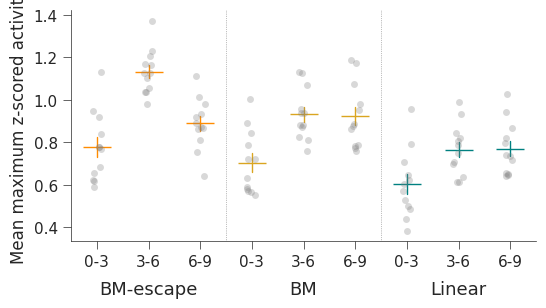

,BM-escape_0-3,BM-escape_3-6,BM-escape_6-9,BM_0-3,BM_3-6,BM_6-9,Linear_0-3,Linear_3-6,Linear_6-9
0,0.618474,1.034851,0.639717,0.579337,0.873769,0.787578,0.485469,0.819672,0.739945
1,0.920102,1.374084,1.112610,0.842736,1.127578,1.173588,0.793540,0.931273,0.868400
2,0.656008,1.036509,0.755665,0.586856,0.824005,0.781193,0.526493,0.707149,0.714350
3,0.683104,1.162510,0.873957,0.564304,0.879825,0.977846,0.383046,0.610612,0.641962
4,0.622586,1.230181,0.863554,0.568641,0.879226,0.874006,0.438381,0.611272,0.656296
5,0.776659,1.168584,1.014908,0.722256,1.071821,0.951054,0.621970,0.746983,0.737016
6,0.836883,1.205733,0.981035,0.890970,1.132487,1.185582,0.708594,0.842957,1.026302
7,0.590675,0.979660,0.809688,0.551642,0.757555,0.760372,0.498640,0.634032,0.643554
8,1.132053,1.101736,0.891007,1.005788,0.938392,0.774131,0.954724,0.991464,0.941184
9,0.775780,1.125181,0.916636,0.722506,0.935444,1.073402,0.570789,0.788205,0.797133


In [ ]:
subpanel = '4f'

# PLOT
print('Each point is average of all cells in a fish')
groups = group_values.keys()
summary_data = group_values.values()
# stim_colorz_tmp = [i for i in ["sandybrown","cornflowerblue","seagreen"] for t in range(3)]
stim_colorz_tmp = [i for i in ["darkorange","goldenrod","teal"] for t in range(3)]
plt.figure(figsize=[6,3])
sns.stripplot(data=group_values,color='gray',alpha=0.3,size=5)
sns.pointplot(data=group_values,palette=stim_colorz_tmp,\
              linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);

plt.ylabel('Mean maximum z-scored activity')
xlabels = [f"{m}" for n in ['BM-escape','BM','Linear'] for m in peak_timings]
plt.xticks(range(len(xlabels)),xlabels,fontsize=11)
for i, stim in enumerate(['BM-escape','BM','Linear']): plt.text(3*i+1,plt.ylim()[0]-0.25,stim,ha='center',fontsize=13)
plt.axvline(len(peak_timings)-0.5,color='gray',ls=':',lw=0.5); plt.axvline(len(peak_timings)*2-0.5,color='gray',ls=':',lw=0.5)
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
for key, lst in group_values.items():
  series_dict[key] = lst
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+".csv", index=False)

# 4g - mean psth social vs general offset

In [15]:
giant_list = {'BM':[], 'BM-escape':[], 'Linear':[], 'pk_Linear':[], 'pk_BM':[], 'pk_BM-escp':[], 'fish_id':[]}

for exp, ffile, plane_num, trial_num in zip(experiments[:], fcn_files[:], planeNum[:], trialNum[:]):
  load_path = data_path + exp + '/' + ffile + '/'; output_path = save_path + exp + '/' + ffile + '/'
  # print("fish #", exp, ': ', ffile)

  # get cell respnse metrics
  data = np.load(output_path+'ttest_cells_long.npz', allow_pickle=True)
  cell_id, resp_arr = data['cell_id'], data['resp_arr']
  # filters for resp type
  swim_only = ((resp_arr[2,:])*(~resp_arr[3,:])); escp_only = ((~resp_arr[2,:])*(resp_arr[3,:]))
  both = ((resp_arr[2,:])*(resp_arr[3,:])); either = ((resp_arr[2,:])+(resp_arr[3,:]))
  # exclude loom only cells
  loom_only = ((~resp_arr[0,:])*(resp_arr[1,:])*(~resp_arr[2,:])*(~resp_arr[3,:]))
  exclude = (~loom_only)
  if np.sum(exclude) == 0: continue # skip if there's no such cells

  # load PSTHs
  with open(output_path+'PSTHs.pkl', 'rb') as f:
    PSTHs = pickle.load(f) # cell_num x stim_types x x [trial_num for stim in stim_names]
  # compile responses
  big_list = {'Linear':[], 'BM':[], 'BM-escape':[]}
  for cell in cell_id[exclude]:
    # append the average psth to master list
    Linear = np.mean(np.array(PSTHs[cell][0]),axis=0); big_list['Linear'].append(Linear)
    BM = np.mean(np.array(PSTHs[cell][2]),axis=0); big_list['BM'].append(BM)
    BM_escp = np.mean(np.array(PSTHs[cell][3]),axis=0); big_list['BM-escape'].append(BM_escp)
  for key, lst in big_list.items(): big_list[key] = np.array(lst)

  # get METRICS of interest
  ## time to peak
  window = np.arange(pre,pre+stim_dur+off)
  pk_Linear = np.argmax(big_list['Linear'][:,window],axis=1); big_list['pk_Linear'] = pk_Linear/resample_Hz
  pk_BM = np.argmax(big_list['BM'][:,window],axis=1); big_list['pk_BM'] = pk_BM/resample_Hz
  pk_BM_escp = np.argmax(big_list['BM-escape'][:,window],axis=1); big_list['pk_BM-escp'] = pk_BM_escp/resample_Hz

  # append to across fish SUMMARY
  giant_list['Linear'].extend(big_list['Linear'])
  giant_list['BM'].extend(big_list['BM'])
  giant_list['BM-escape'].extend(big_list['BM-escape'])
  giant_list['pk_Linear'].extend(big_list['pk_Linear'])
  giant_list['pk_BM'].extend(big_list['pk_BM'])
  giant_list['pk_BM-escp'].extend(big_list['pk_BM-escp'])
  giant_list['fish_id'].extend([exp] * np.sum(exclude))

  # break
for key, lst in giant_list.items():
  if key != 'fish_id': giant_list[key] = np.array(lst)


Compare psth in social offset cells:
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/4g-social offset-psth


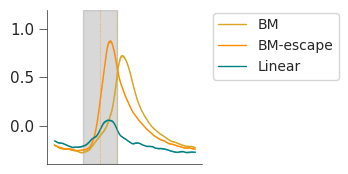

n = 5237 cells
Ns (fish), means, and sems for data:
BM: N_fish=12, mean=1.068, sem=0.060
BM-escape: N_fish=12, mean=1.208, sem=0.041
Linear: N_fish=12, mean=0.579, sem=0.038

Compare psth in general offset cells:
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/4g-general offset-psth


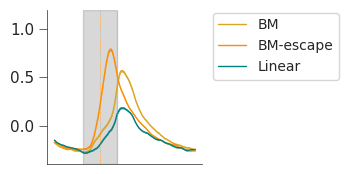

n = 2970 cells
Ns (fish), means, and sems for data:
BM: N_fish=12, mean=0.984, sem=0.043
BM-escape: N_fish=12, mean=1.146, sem=0.038
Linear: N_fish=12, mean=0.631, sem=0.034


In [39]:
# all offset = any(swim_6-9, escape_3-6, sphere_6-9)
# social offset = (swim_6-9 AND escape_3-6) NOT sphere_6-9
# general offset = (swim_6_9 AND escape_3-6) AND sphere_6-9

subpanel = '4g'
response_window = np.arange(pre,pre+stim_dur+off)

cell_types = ['social offset','general offset']
group_values = {}

fish_data_for_mlm = []  # Will contain individual cell data for MLM

# initiate dict to save source data into csv
series_dict = {}
for cell_type in cell_types:
  summary_data = []  # Will contain fish means for each group
  print(f"\nCompare psth in {cell_type} cells:")
  if cell_type == 'social offset':
    filter1 = (giant_list['pk_BM'] >= 6)
    filter2 = (giant_list['pk_BM-escp'] >= 3)*(giant_list['pk_BM-escp'] < 6)
    filter3 = (giant_list['pk_Linear'] < 6)
    filter_mask = filter1 * filter2 * filter3
    # break
  if cell_type == 'general offset':
    filter1 = (giant_list['pk_BM'] >= 6)
    filter2 =  (giant_list['pk_BM-escp'] >= 3)*(giant_list['pk_BM-escp'] < 6)
    filter3 = (giant_list['pk_Linear'] >= 6)
    filter_mask = filter1 * filter2 * filter3

  # get mean psth of filtered cells
  stim_responses = []
  for stim in ['BM','BM-escape','Linear']:
    stim_responses.append(giant_list[stim][filter_mask])
  fish_ids_filtered = np.array(giant_list['fish_id'])[filter_mask]

  # visualize psth
  plt.figure(figsize=[2,2])
  for istim, stim in enumerate(['BM','BM-escape','Linear']):
    tmp = np.array(stim_responses[istim])
    plt.plot(np.nanmean(tmp,axis=0),c=list(np.array(stim_colorz)[[2,3,0]])[istim],lw=1,label=stim)
    plt.fill_between(np.arange(trial_len), np.nanmean(tmp,axis=0)+stats.sem(tmp,axis=0,nan_policy='omit'), \
                      np.nanmean(tmp,axis=0)-stats.sem(tmp,axis=0,nan_policy='omit'),color=list(np.array(stim_colorz)[[2,3,0]])[istim],alpha=0.8,lw=0)

    # save
    for idx, t in enumerate(tmp):
      series_dict[f'{cell_type}_{stim}_{idx}'] = pd.Series(t)

  plt.axvline(pre+stim_dur/2,c=stim_colorz[3],ls=':',lw=0.5) # escape timing
  plt.axvline(pre+stim_dur,c=stim_colorz[2],ls=':',lw=0.5) # swim offset timing
  plt.legend(bbox_to_anchor=(1.05,1),markerscale=0.7,borderaxespad=0.2,fontsize=10)
  plt.axvspan(pre, pre+stim_dur, color='gray', alpha=0.3)
  sns.despine(); plt.xticks([]); plt.ylim(-0.4,1.2)
  print(figure_path+subpanel+f"-{cell_type}-psth")
  # plt.savefig(figure_path+subpanel+f"-{cell_type}-psth.pdf",bbox_inches='tight')
  plt.show()

  for istim, stim in enumerate(['BM','BM-escape','Linear']):
    # Calculate maximum response for each cell
    max_responses = []; fish_ids_for_mlm = []
    for cell_response, fish_id in zip(stim_responses[istim], fish_ids_filtered):
      max_response = np.max(cell_response[response_window])
      max_responses.append(max_response)
      fish_ids_for_mlm.append(fish_id)
    # Store individual cell data for MLM
    fish_data_for_mlm.extend([(cell_type, max_resp, fish_id) for max_resp, fish_id in zip(max_responses, fish_ids_for_mlm)])

    # Calculate fish means
    fish_means = []
    for fish in np.unique(fish_ids_filtered):
      fish_mask = fish_ids_filtered == fish;
      fish_mean = np.mean(np.array(max_responses)[fish_mask])
      fish_means.append(fish_mean)
    summary_data.append(fish_means)
    group_values[f"{stim}_{cell_type}"] = fish_means

  # Print basic statistics
  print(f"n = {np.sum(filter_mask)} cells")
  print("Ns (fish), means, and sems for data:")
  for id, s in enumerate(summary_data):
      print(f"{['BM','BM-escape','Linear'][id]}: N_fish={len(s)}, mean={np.mean(s):.3f}, sem={scipy.stats.sem(s):.3f}")


Compare psth in social offset cells:
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/4g-social offset-psth


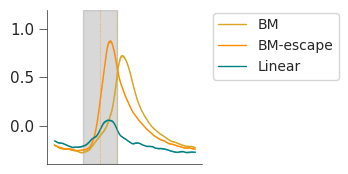

n = 15711 cells
Ns (fish), means, and sems for data:
BM: N_fish=12, mean=1.068, sem=0.060
BM-escape: N_fish=12, mean=1.208, sem=0.041
Linear: N_fish=12, mean=0.579, sem=0.038

Compare psth in general offset cells:
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/4g-general offset-psth


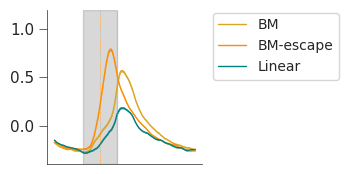

n = 24621 cells
Ns (fish), means, and sems for data:
BM: N_fish=12, mean=0.984, sem=0.043
BM-escape: N_fish=12, mean=1.146, sem=0.038
Linear: N_fish=12, mean=0.631, sem=0.034


,social offset_BM_0,social offset_BM_1,social offset_BM_2,social offset_BM_3,social offset_BM_4,social offset_BM_5,social offset_BM_6,social offset_BM_7,social offset_BM_8,social offset_BM_9,...,general offset_Linear_2960,general offset_Linear_2961,general offset_Linear_2962,general offset_Linear_2963,general offset_Linear_2964,general offset_Linear_2965,general offset_Linear_2966,general offset_Linear_2967,general offset_Linear_2968,general offset_Linear_2969
0,0.145260,-0.362628,-0.233839,-0.375264,-0.016810,-0.225687,-0.120482,-0.613913,0.113156,0.059666,...,0.557993,-0.052091,-0.568041,0.174202,-0.135647,-0.483782,-0.515040,-0.017618,0.282356,0.170132
1,0.124161,-0.338236,-0.154898,-0.309368,-0.057806,-0.142479,-0.098185,-0.551665,0.123876,-0.057019,...,0.420790,-0.094853,-0.479261,0.154950,-0.016551,-0.481803,-0.453939,-0.097401,0.223357,0.254775
2,0.127583,-0.261801,-0.050659,-0.298207,-0.044677,-0.030157,-0.047800,-0.538217,0.026638,0.063948,...,0.273460,-0.160824,-0.238052,0.152291,0.032677,-0.548131,-0.417322,-0.280691,0.212984,0.305211
3,0.114014,-0.184244,0.104615,-0.329762,0.010369,0.037201,0.025865,-0.558059,-0.110835,0.216614,...,0.152366,-0.157359,-0.047502,0.238148,0.097986,-0.642265,-0.389125,-0.423850,0.256508,0.328040
4,0.153173,-0.176417,0.266803,-0.356852,-0.023889,0.010709,0.087892,-0.541019,-0.179760,0.203417,...,0.124884,-0.136864,0.028300,0.349285,0.183848,-0.674447,-0.343348,-0.568305,0.275273,0.305641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,-0.659696,0.062522,-0.189654,-0.190923,-0.073534,0.159488,-0.634792,0.309222,-0.438674,-0.622227,...,0.050722,-0.632969,0.310223,-0.581443,-0.534319,-0.121693,-0.335055,0.146930,-0.336219,-0.406465
246,-0.635086,0.006149,-0.181978,-0.166742,-0.084573,0.195164,-0.602460,0.253894,-0.572397,-0.609921,...,0.214507,-0.718044,0.428751,-0.645651,-0.582116,-0.146398,-0.402748,0.213526,-0.392557,-0.288633
247,-0.600489,0.002750,-0.071052,-0.141771,-0.105739,0.211148,-0.575257,0.141751,-0.689370,-0.563500,...,0.337329,-0.766521,0.471901,-0.708631,-0.640152,-0.128820,-0.467381,0.273741,-0.530410,-0.158168
248,-0.556432,0.010390,-0.020948,-0.157063,-0.087934,0.277939,-0.524776,0.079632,-0.741400,-0.462181,...,0.353740,-0.733066,0.488614,-0.778221,-0.589680,-0.204163,-0.481413,0.325124,-0.610525,-0.132153


In [ ]:
# all offset = any(swim_6-9, escape_3-6, sphere_6-9)
# social offset = (swim_6-9 AND escape_3-6) NOT sphere_6-9
# general offset = (swim_6_9 AND escape_3-6) AND sphere_6-9

subpanel = '4g'
response_window = np.arange(pre,pre+stim_dur+off)

cell_types = ['social offset','general offset']
group_values = {}

fish_data_for_mlm = []  # Will contain individual cell data for MLM

# initiate dict to save source data into csv
series_dict = {}
for cell_type in cell_types:
  summary_data = []  # Will contain fish means for each group
  print(f"\nCompare psth in {cell_type} cells:")
  if cell_type == 'social offset':
    filter1 = (giant_list['pk_BM'] >= 6)
    filter2 = (giant_list['pk_BM-escp'] >= 3)*(giant_list['pk_BM-escp'] < 6)
    filter3 = (giant_list['pk_Linear'] < 6)
    filter_mask = filter1 * filter2 * filter3
  elif cell_type == 'general offset':
    filter1 = (giant_list['pk_BM'] >= 6)
    filter2 =  (giant_list['pk_BM-escp'] >= 3)*(giant_list['pk_BM-escp'] < 6)
    filter3 = (giant_list['pk_Linear'] >= 6)
    filter_mask = filter1 * filter2 * filter3

  # get mean psth of filtered cells
  stim_responses = []
  for stim in ['BM','BM-escape','Linear']:
    stim_responses.append(giant_list[stim][filter_mask])
  fish_ids_filtered = np.array(giant_list['fish_id'])[filter_mask]

  # visualize psth
  plt.figure(figsize=[2,2])
  for istim, stim in enumerate(['BM','BM-escape','Linear']):
    tmp = np.array(stim_responses[istim])
    plt.plot(np.nanmean(tmp,axis=0),c=list(np.array(stim_colorz)[[2,3,0]])[istim],lw=1,label=stim)
    plt.fill_between(np.arange(trial_len), np.nanmean(tmp,axis=0)+stats.sem(tmp,axis=0,nan_policy='omit'), \
                      np.nanmean(tmp,axis=0)-stats.sem(tmp,axis=0,nan_policy='omit'),color=list(np.array(stim_colorz)[[2,3,0]])[istim],alpha=0.8,lw=0)

    # save
    for idx, t in enumerate(tmp):
      series_dict[f'{cell_type}_{stim}_{idx}'] = pd.Series(t)

  plt.axvline(pre+stim_dur/2,c=stim_colorz[3],ls=':',lw=0.5) # escape timing
  plt.axvline(pre+stim_dur,c=stim_colorz[2],ls=':',lw=0.5) # swim offset timing
  plt.legend(bbox_to_anchor=(1.05,1),markerscale=0.7,borderaxespad=0.2,fontsize=10)
  plt.axvspan(pre, pre+stim_dur, color='gray', alpha=0.3)
  sns.despine(); plt.xticks([]); plt.ylim(-0.4,1.2)
  print(figure_path+subpanel+f"-{cell_type}-psth")
  # plt.savefig(figure_path+subpanel+f"-{cell_type}-psth.pdf",bbox_inches='tight')
  plt.show()

  for istim, stim in enumerate(['BM','BM-escape','Linear']):
    # Calculate maximum response for each cell
    max_responses = []; fish_ids_for_mlm = []
    for cell_response, fish_id in zip(stim_responses[istim], fish_ids_filtered):
      max_response = np.max(cell_response[response_window])
      max_responses.append(max_response)
      fish_ids_for_mlm.append(fish_id)
    # Store individual cell data for MLM
    fish_data_for_mlm.extend([(cell_type, max_resp, fish_id) for max_resp, fish_id in zip(max_responses, fish_ids_for_mlm)])

    # Calculate fish means
    fish_means = []
    for fish in np.unique(fish_ids_filtered):
      fish_mask = fish_ids_filtered == fish;
      fish_mean = np.mean(np.array(max_responses)[fish_mask])
      fish_means.append(fish_mean)
    summary_data.append(fish_means)
    group_values[f"{stim}_{cell_type}"] = fish_means

  # Print basic statistics
  print(f"n = {len([data[0]=='social offset' for data in fish_data_for_mlm])} cells")
  print("Ns (fish), means, and sems for data:")
  for id, s in enumerate(summary_data):
      print(f"{['BM','BM-escape','Linear'][id]}: N_fish={len(s)}, mean={np.mean(s):.3f}, sem={scipy.stats.sem(s):.3f}")

df = pd.DataFrame(series_dict)
display(df)
# df.to_csv(csv_path+subpanel+".csv", index=False)

# 4h - social vs general offset cell count by brain region

In [52]:
# count from each session

regions = ['forebrain','midbrain','hindbrain']
total_cell_by_region = {n: 0 for n in regions};
ratio_by_region_social = {n: 0 for n in regions}
cell_by_region_social = {n: 0 for n in regions};
cell_by_region_general = {n: 0 for n in regions}

subregions = {'forebrain': ['forebrain','habenula'],'thalamus':['thalamus'],'tectum':['tectum_left','tectum_right'], 'hindbrain':['hindbrain','cerebellum']}
total_cell_by_subregion = {subreg_name: 0 for subreg_name,subreg in subregions.items()}
ratio_by_subregion_social = {subreg_name: 0 for subreg_name,subreg in subregions.items()}
cell_by_subregion_social = {subreg_name: 0 for subreg_name,subreg in subregions.items()}
cell_by_subregion_general = {subreg_name: 0 for subreg_name,subreg in subregions.items()}

social_cell_cnt = 0; general_cell_cnt = 0;
for exp, ffile, plane_num in zip(experiments, fcn_files, planeNum):
  load_path = data_path + exp + '/' + ffile + '/';
  output_path = save_path + exp + '/' + ffile + '/'

  # load anatomy
  with open(load_path+'neuron_anatomy.pkl', 'rb') as f:
    cell_locations = pickle.load(f) # cell_num x stim_types x x [trial_num for stim in stim_names]

  # load PSTHs
  with open(output_path+'PSTHs.pkl', 'rb') as f:
    PSTHs = pickle.load(f) # cell_num x stim_types x x [trial_num for stim in stim_names]

  # get cell respnse metrics
  data = np.load(output_path+'ttest_cells_long.npz', allow_pickle=True)
  cell_id, resp_arr = data['cell_id'], data['resp_arr']
  # filters for resp type
  swim_only = ((resp_arr[2,:])*(~resp_arr[3,:])); escp_only = ((~resp_arr[2,:])*(resp_arr[3,:]))
  both = ((resp_arr[2,:])*(resp_arr[3,:])); either = ((resp_arr[2,:])+(resp_arr[3,:]))
  # exclude loom only cells
  loom_only = ((~resp_arr[0,:])*(resp_arr[1,:])*(~resp_arr[2,:])*(~resp_arr[3,:]))
  exclude = (~loom_only); mask = cell_id[exclude]

  # compile responses
  big_list = {'BM':[], 'BM-escape':[], 'Linear':[]}
  for cell in cell_id[exclude]:
    # append the average psth to master list
    BM = np.mean(np.array(PSTHs[cell][2]),axis=0); big_list['BM'].append(BM)
    BM_escp = np.mean(np.array(PSTHs[cell][3]),axis=0); big_list['BM-escape'].append(BM_escp)
    Linear = np.mean(np.array(PSTHs[cell][0]),axis=0); big_list['Linear'].append(Linear)
  for key, lst in big_list.items(): big_list[key] = np.array(lst)

  # get time to peak
  window = np.arange(pre,pre+stim_dur+off)
  pk_BM = np.argmax(big_list['BM'][:,window],axis=1); big_list['pk_BM'] = pk_BM/resample_Hz
  pk_BM_escp = np.argmax(big_list['BM-escape'][:,window],axis=1); big_list['pk_BM-escp'] = pk_BM_escp/resample_Hz
  pk_Linear = np.argmax(big_list['Linear'][:,window],axis=1); big_list['pk_Linear'] = pk_Linear/resample_Hz

  # get total cell cnt
  for icell in range(len(cell_locations))[::]:
    # print(icell, cell_locations[icell])
    if cell_locations[icell] == []: continue
    for reg in regions:
      if reg in cell_locations[icell]:
        # print(f"part of {reg}")
        total_cell_by_region[reg]+=1
    for subreg_name, subregs in subregions.items():
      for subreg in subregs:
        if subreg in cell_locations[icell]:
          # print(f"also part of {subreg_name}")
          total_cell_by_subregion[subreg_name]+=1

  # filter the social offset cells
  filter1 = (big_list['pk_BM'] >= 6)
  filter2 = (big_list['pk_BM-escp'] >= 3)*(big_list['pk_BM-escp'] < 6)
  filter3 = (big_list['pk_Linear'] < 6)
  filter_mask = filter1 * filter2 * filter3
  social_cell_cnt += np.sum(filter_mask)

  for icell in np.arange(len(cell_locations))[mask][filter_mask]:
    # print(icell, cell_locations[icell])
    if cell_locations[icell] == []: continue
    for reg in regions:
      if reg in cell_locations[icell]:
        # print(f"part of {reg}")
        cell_by_region_social[reg]+=1
    for subreg_name, subregs in subregions.items():
      for subreg in subregs:
        if subreg in cell_locations[icell]:
          # print(f"also part of {subreg_name}")
          cell_by_subregion_social[subreg_name]+=1
  ratio_by_region_social = {n: cell_by_region_social[n]/total_cell_by_region[n]*100 for n in regions}
  ratio_by_subregion_social = {n: cell_by_subregion_social[n]/total_cell_by_subregion[n]*100 for n, _ in subregions.items()}

  # filter the general offset cells
  filter1 = (big_list['pk_BM'] >= 6)
  filter2 = (big_list['pk_BM-escp'] >= 3)*(big_list['pk_BM-escp'] < 6)
  filter3 = (big_list['pk_Linear'] >= 6)
  filter_mask = filter1 * filter2 * filter3
  general_cell_cnt += np.sum(filter_mask)

  for icell in np.arange(len(cell_locations))[mask][filter_mask]:
    # print(icell, cell_locations[icell])
    if cell_locations[icell] == []: continue
    for reg in regions:
      if reg in cell_locations[icell]:
        # print(f"part of {reg}")
        cell_by_region_general[reg]+=1
    for subreg_name, subregs in subregions.items():
      for subreg in subregs:
        if subreg in cell_locations[icell]:
          # print(f"also part of {subreg_name}")
          cell_by_subregion_general[subreg_name]+=1
  ratio_by_region_general = {n: cell_by_region_general[n]/total_cell_by_region[n]*100 for n in regions}
  ratio_by_subregion_general = {n: cell_by_subregion_general[n]/total_cell_by_subregion[n]*100 for n, _ in subregions.items()}
  # break
print('done')
print(f"social offset cell count: {social_cell_cnt}")
print(f"general offset cell count: {general_cell_cnt}")

done
social offset cell count: 5237
general offset cell count: 2970


/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/4h


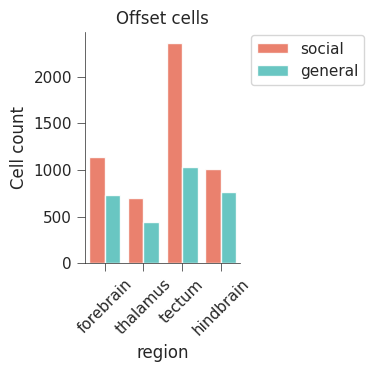

,region,count,cell_type
0,forebrain,1137,social
1,thalamus,702,social
2,tectum,2357,social
3,hindbrain,1012,social
0,forebrain,736,general
1,thalamus,439,general
2,tectum,1032,general
3,hindbrain,763,general


In [ ]:
subpanel = '4h'
pal_color = ['tomato','mediumturquoise']

# cell counts
df1 = pd.DataFrame(list(cell_by_subregion_social.items()), columns=["region", "count"]); df1['cell_type'] = 'social'
df2 = pd.DataFrame(list(cell_by_subregion_general.items()), columns=["region", "count"]); df2['cell_type'] = 'general'
summary_data = pd.concat([df1,df2], ignore_index=False)

# PLOT
plt.figure(figsize=[2,3])
sns.barplot(data=summary_data,x='region',y='count',hue='cell_type',palette=pal_color,alpha=0.9)
plt.ylabel('Cell count'); plt.xticks(rotation=45); sns.despine(); plt.title('Offset cells')
plt.legend(bbox_to_anchor=(1.05,1),markerscale=0.7,borderaxespad=0.2)
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

# save source data into csv
display(summary_data)
df = pd.DataFrame(summary_data);
df.to_csv(csv_path+subpanel+'.csv')